In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel(r"C:\Users\HP\OneDrive\Documents\Desktop\Data.xlsx")

In [22]:
print(df.isnull().sum())
# Handle missing numerical values using the median
df = df.fillna(df.median(numeric_only=True))
# Remove rows with missing categorical values
df = df.dropna()

Order Id              0
Date                  0
Region                0
Salesperson           0
Product               0
Quantity Sold         2
Sales Amount          2
Discount (%)          1
Profit Margin (%)     1
Total Sales Amount    6
dtype: int64


In [23]:
# 2. Are there any duplicate records, and how can they be handled?
print("Duplicate records:", 
    df.duplicated().sum()
)
df = df.drop_duplicates()

Duplicate records: 0


In [26]:
# 3.Total sales generated by each region
region_sales = df.groupby("Region")["Total Sales Amount"].sum()
print(region_sales)

Region
East     11532000.0
North    12634000.0
South    16082000.0
West     12512000.0
Name: Total Sales Amount, dtype: float64


In [25]:
# 4.Total sales generated by each product
product_sales = df.groupby("Product")["Total Sales Amount"].sum()
print(product_sales)

Product
Product X    13718000.0
Product Y    17862000.0
Product Z    21180000.0
Name: Total Sales Amount, dtype: float64


In [27]:
# 5.Top-performing salesperson based on total sales
salesperson_sales = (
    df.groupby("Salesperson")["Total Sales Amount"].sum().sort_values(ascending=False)
)
print(salesperson_sales)

Salesperson
Meera Reddy     16082000.0
Rajesh Patel    12634000.0
Priya Sharma    12512000.0
Arun Kumar      11532000.0
Name: Total Sales Amount, dtype: float64


In [28]:
# 6.Region with highest average profit margin
region_profit = (
    df.groupby("Region")["Profit Margin (%)"].mean().sort_values(ascending=False)
)
print(region_profit)

Region
South    27.181818
East     23.130435
West     22.913043
North    22.454545
Name: Profit Margin (%), dtype: float64


In [29]:
#7. Product generates the highest estimated profit
df["Estimated Profit"] = (df["Total Sales Amount"] * df["Profit Margin (%)"] / 100
)
product_profit = (
    df.groupby("Product")["Estimated Profit"].sum().sort_values(ascending=False)
)
print(product_profit)

Product
Product Z    5409820.0
Product Y    4435360.0
Product X    3128740.0
Name: Estimated Profit, dtype: float64


In [30]:
# 8.Highest quantity sold product
product_quantity = (
    df.groupby("Product")["Quantity Sold"].sum().sort_values(ascending=False)
)
print(product_quantity)

Product
Product Z    5550.0
Product Y    5170.0
Product X    4410.0
Name: Quantity Sold, dtype: float64


In [31]:
# 9.Top 5 highest-value orders
top_5_orders = df.nlargest(5, "Total Sales Amount")
print(top_5_orders)

    Order Id       Date Region   Salesperson    Product  Quantity Sold  \
3       1004 2024-01-04  South   Meera Reddy  Product Z          250.0   
33      1034 2024-02-04  South   Meera Reddy  Product Y          230.0   
61      1062 2024-03-03  South   Meera Reddy  Product Z          230.0   
37      1038 2024-02-08  South   Meera Reddy  Product Z          220.0   
60      1061 2024-03-02  North  Rajesh Patel  Product Y          220.0   

    Sales Amount  Discount (%)  Profit Margin (%)  Total Sales Amount  \
3         5000.0          20.0               30.0           1250000.0   
33        4600.0          10.0               28.0           1058000.0   
61        4600.0          17.0               30.0           1058000.0   
37        4400.0          18.0               30.0            968000.0   
60        4400.0           9.0               25.0            968000.0   

    Estimated Profit  
3           375000.0  
33          296240.0  
61          317400.0  
37          290400.0  
6

In [32]:
# 10. Total sales vary by month
df["Date"] = pd.to_datetime(df["Date"])
monthly_sales = (
    df.groupby(df["Date"].dt.month_name())["Total Sales Amount"].sum()
)
print(monthly_sales)

Date
February    16568000.0
January     17050000.0
March       19142000.0
Name: Total Sales Amount, dtype: float64


In [12]:
# 11. Average and median sales amounts
sales = df["Total Sales Amount"].to_numpy()
print("Average:", np.mean(sales))
print("Median:", np.median(sales))

Average: 586222.2222222222
Median: 578000.0


In [33]:
# 12. Minimum, maximum, and standard deviation of sales
sales = df["Total Sales Amount"].to_numpy()
print("Minimum:", np.min(sales))
print("Maximum:", np.max(sales))
print("Standard Deviation:", np.std(sales))

Minimum: 200000.0
Maximum: 1250000.0
Standard Deviation: 210110.32963013492


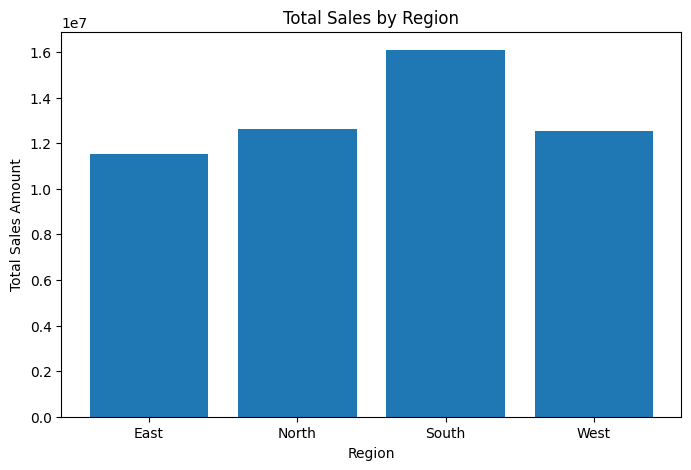

In [34]:
# 13. Bar Chart: Compare total sales across regions
region_sales = df.groupby("Region")["Total Sales Amount"].sum()
plt.figure(figsize=(8, 5))
plt.bar(region_sales.index, region_sales.values)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales Amount")
plt.show()

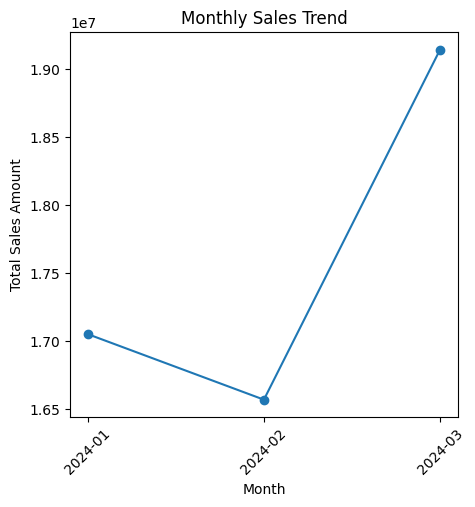

In [37]:
# 14. Line Chart: Analyzed monthly sales trends
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Total Sales Amount"].sum()
)
plt.figure(figsize=(5, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.show()

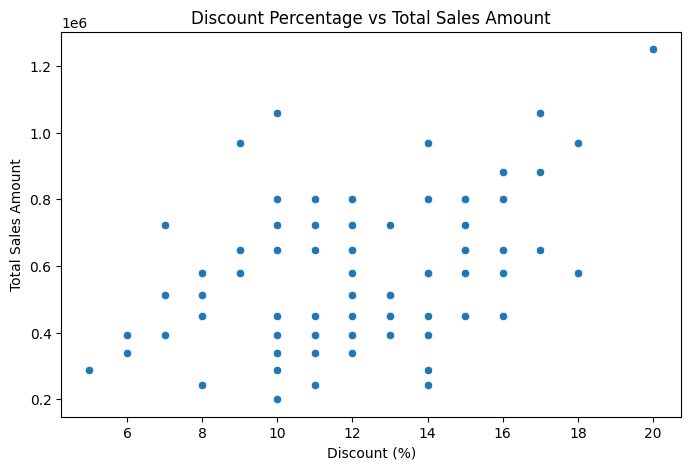

In [36]:
# 15. Scatter Plot: Analyzed the relationship between discount and sales
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Discount (%)",
    y="Total Sales Amount"
)
plt.title("Discount Percentage vs Total Sales Amount")
plt.show()